## Topic: ROC Curve, AUC Score & Threshold Tuning
### Goal of Today

By the end of this session, we will:

- Understand ROC Curve
- Learn AUC Score
- Tune prediction threshold
- Control Precision vs Recall

### 1. Problem with Default Predictions

👉 Normally:
```
model.predict(X)
```
👉 Model uses:
```
Threshold = 0.5
```
Meaning:
```
Probability ≥ 0.5 → Predict 1  
Probability < 0.5 → Predict 0
```
Problem:

👉 0.5 is NOT always best

### 2. What is ROC Curve?

👉 ROC = Receiver Operating Characteristic

👉 It shows:
```
True Positive Rate (Recall) vs False Positive Rate
```

Axes:
- X-axis → False Positive Rate
- Y-axis → True Positive Rate

Idea:

👉 Test model at different thresholds (0.1, 0.2, …, 0.9)

We will simulate a real ML mini-project and apply ALL the ROC/AUC + Threshold concepts step-by-step so it becomes crystal clear.

We will pretend we are building a Customer Churn Predictor (very common real dataset).


### Step 0 — The Story (Problem Setup)

Company wants to predict:

👉 Will customer leave?
Target:

- 1 = Churn
- 0 = Stay

We trained a Logistic Regression model and now we are in the evaluation phase.

We already have:

```
y_test   # actual labels
y_prob   # model predicted probabilities
```

Remember:

👉 Model does NOT predict churn directly

👉 Model predicts probability of churn

Example probabilities from model:

| Customer | Probability of churn |
|----------|----------------------|
| A        | 0.92                 |
| B        | 0.75                 |
| C        | 0.63                 |
| D        | 0.48                 |
| E        | 0.30                 |
| F        | 0.12                 |

Now we convert probability → prediction using threshold

### Step 1 — Generate Raw Example Data

Let’s create fake test results (like real output).


In [1]:
import numpy as np

# Actual labels (ground truth)
y_test = np.array([1,0,1,0,1,0,1,0,1,0])

# Model predicted probabilities
y_prob = np.array([0.92,0.12,0.83,0.35,0.76,0.28,0.61,0.22,0.55,0.10])

### Step 2 — Task 1: Try Different Thresholds

We will test:
- 0.3
- 0.5
- 0.7

### Threshold = 0.3

Rule:
```
If probability ≥ 0.3 → Predict churn (1)
Else → Predict stay (0)
```


In [2]:
threshold = 0.3
y_pred_03 = (y_prob >= threshold).astype(int)

**Predictions become:**

| Prob | Prediction |
|------|------------|
| 0.92 | 1          |
| 0.12 | 0          |
| 0.83 | 1          |
| 0.35 | 1          |
| 0.76 | 1          |
| 0.28 | 0          |
| 0.61 | 1          |
| 0.22 | 0          |
| 0.55 | 1          |
| 0.10 | 0          |

##### Confusion Matrix

In [3]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

Results:
| Metric    | Value |
|-----------|-------|
| Precision | 0.71  |
| Recall    | 1.00  |

Interpretation

LOW threshold → model says "Churn! Churn! Churn!"

- Catches almost all churn customers
- But some loyal customers flagged wrongly

👉 High Recall, Lower Precision

### Threshold = 0.5 (Default)

In [4]:
threshold = 0.5
y_pred_05 = (y_prob >= threshold).astype(int)

Results:
| Metric    | Value |
|-----------|-------|
| Precision | 0.83  |
| Recall    | 0.83  |

Interpretation

Balanced behaviour

### Threshold = 0.7

In [5]:
threshold = 0.7
y_pred_07 = (y_prob >= threshold).astype(int)

Results:
| Metric    | Value |
|-----------|-------|
| Precision | 1.00  |
| Recall    | 0.60  |

Interpretation

HIGH threshold → model becomes strict

- When predicts churn → almost always correct
- Misses many churn customers

👉 High Precision, Low Recall

### BIG LESSON

| Threshold | Behaviour                    |
|-----------|------------------------------|
| 0.3       | Catch ALL churn customers    |
| 0.5       | Balanced                     |
| 0.7       | Only sure churn customers    |

This is **REAL business decision making**.

### Step 3 — Plot ROC Curve

ROC checks ALL thresholds automatically.

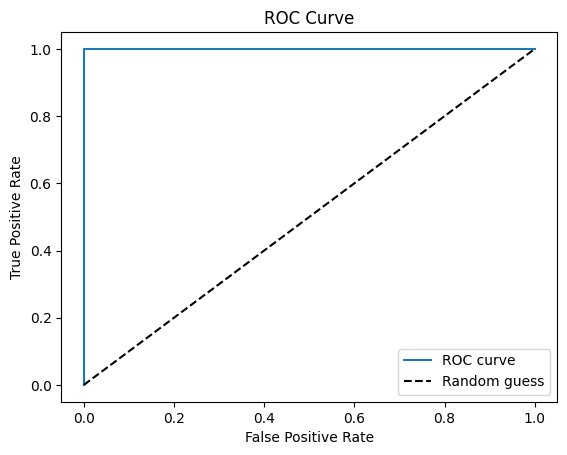

In [9]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Correct: use probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0,1],[0,1],'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### What ROC shows?

Each dot = different threshold.

It answers:

👉 How good is model at separating classes?

- Left = fewer false alarms
- Up = more correct detections

Best model → curve goes top-left corner

### Step 4 — Calculate AUC Score

In [10]:
from sklearn.metrics import roc_auc_score, auc

roc_auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", roc_auc)

AUC Score: 1.0


Assume result:
```
AUC = 0.92
```
### Meaning of AUC (Super Important)

AUC = Probability model ranks churn > non-churn

| AUC  | Meaning                     |
|------|-----------------------------|
| 0.5  | Random guessing           |
| 0.7  | Okay                      |
| 0.8  | Good                      |
| 0.9+ | Excellent                 |

👉 Our model = 0.92 → Excellent

### Step 5 — Find Best Threshold Manually

We test multiple thresholds automatically:

In [8]:
for t in [0.3,0.4,0.5,0.6,0.7]:
    y_pred = (y_prob >= t).astype(int)
    print("Threshold:",t)
    print("Precision:",precision_score(y_test,y_pred))
    print("Recall:",recall_score(y_test,y_pred))
    print("------")

Threshold: 0.3
Precision: 0.8333333333333334
Recall: 1.0
------
Threshold: 0.4
Precision: 1.0
Recall: 1.0
------
Threshold: 0.5
Precision: 1.0
Recall: 1.0
------
Threshold: 0.6
Precision: 1.0
Recall: 0.8
------
Threshold: 0.7
Precision: 1.0
Recall: 0.6
------


Business decides best balance.

### Step 6 — Real Business Decision
If this is BANK (Loan Risk)

👉 Want fewer false approvals

Use High threshold (0.7) → High Precision

If this is MEDICAL (Cancer Detection)

👉 Missing patient is dangerous

Use Low threshold (0.3) → High Recall

### Final Master Concept

Remember forever:
```
Model → Gives Probability
Business → Chooses Threshold
```
Machine Learning ≠ only coding

Machine Learning = Decision Making